<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/Haar_regularization_under_unified_and_decomposition_strategies_for_the_oscillatory%E2%80%93discontinuous_test_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3929727539.py:34: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Haar Regularization of $f(x) = \sin(4\pi x) + \chi_{[0.5,1)}(x)$', fontsize=14)


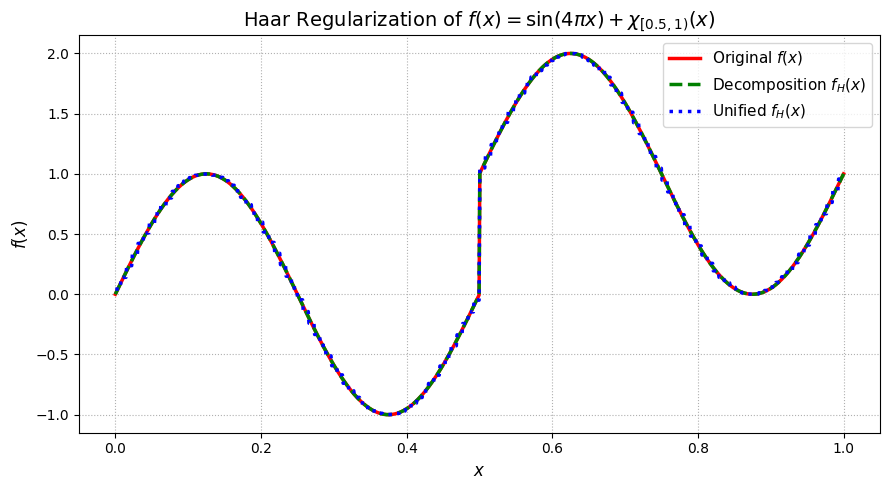

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Domain discretization
x = np.linspace(0, 1, 1024)
dx = x[1] - x[0]

# Original function: sinusoidal + discontinuity
f_sin = np.sin(4 * np.pi * x)
f_jump = (x >= 0.5).astype(float)
f_orig = f_sin + f_jump

# Haar regularization function
def haar_regularize(signal, level=3):
    coeffs = pywt.wavedec(signal, 'haar', level=level)
    coeffs_trunc = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    return pywt.waverec(coeffs_trunc, 'haar')[:len(signal)]

# Unified strategy: regularize full function
f_unified = haar_regularize(f_orig, level=3)

# Decomposition strategy: regularize only jump part
f_jump_reg = haar_regularize(f_jump, level=3)
f_decomp = f_sin + f_jump_reg

# Visualization
plt.figure(figsize=(9, 5))
plt.plot(x, f_orig, 'r-', linewidth=2.5, label='Original $f(x)$')
plt.plot(x, f_decomp, 'g--', linewidth=2.5, label='Decomposition $f_H(x)$')
plt.plot(x, f_unified, 'b:', linewidth=2.5, label='Unified $f_H(x)$')
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$f(x)$', fontsize=12)
plt.title('Haar Regularization of $f(x) = \sin(4\pi x) + \chi_{[0.5,1)}(x)$', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()
